# **MODEL INFERENCE**
___
penjelasan

___
**Nama** : Rafi Arya Siregar

**Batch** : HCK-028

**Obyektif** : Melakukan model inference untuk mendeteksi obyek gambar menggunakan best_model ResNet 50 + Dropout.
___

In [40]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing import image

Library yang digunakan

In [41]:
inference_fold = 'C:/Users/rafiu/OneDrive/Documents/Hacktiv8/PHASE 2/WEEK 1/GC7/p2-ftds028-hck-g7-rafisiregar1444/inference_files'
print(inference_fold + "/")

C:/Users/rafiu/OneDrive/Documents/Hacktiv8/PHASE 2/WEEK 1/GC7/p2-ftds028-hck-g7-rafisiregar1444/inference_files/


Menentukan path direktori data inference yang diambil pada gambar internet

In [42]:
# Gabungkan semua ekstensi
inf_files = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    inf_files.extend(glob.glob(os.path.join(inference_fold, ext)))

# Ambil hanya nama filenya (tanpa path)
file_names = [os.path.basename(path) for path in inf_files]

# Contoh tampilkan 5 nama file pertama
print("Contoh nama file:", file_names[:5])
print(f"Total gambar ditemukan: {len(file_names)}")

Contoh nama file: ['dry.jpg', 'oily.jpg', 'oily2.jpg', 'normal.jpeg']
Total gambar ditemukan: 4


Mengumpulkan semua file gambar dengan format .jpeg dari direktori inferensi, terdapat 6 gambar pada data inferensi

In [43]:
model = tf.keras.models.load_model('best_model_r50.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
[[0.30235848 0.5596449  0.1379967 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
[[0.4876212  0.41242704 0.09995176]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
[[0.34023827 0.52884096 0.13092075]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
[[0.32169393 0.54248357 0.13582255]]


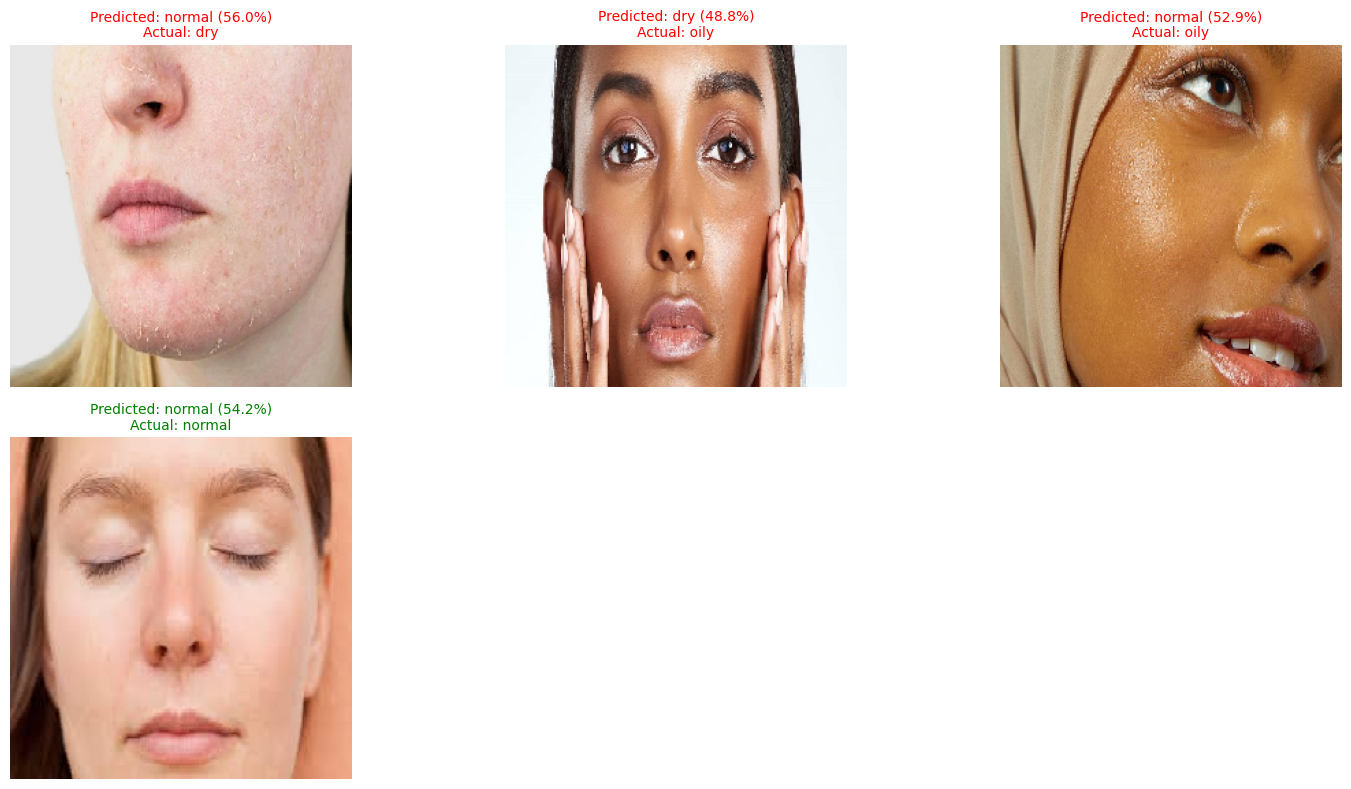

In [54]:
# === CLASS LABELS ===
class_labels = ['dry', 'normal', 'oily']

# === INFERENCE PLOT ===
plt.figure(figsize=(15, 8))

for idx, img_path in enumerate(inf_files[:6]):  # ambil 6 gambar pertama
    filename = os.path.basename(img_path).lower()

    # Cek apakah ada salah satu label di dalam nama file
    actual_label = next((label for label in class_labels if label in filename), 'unknown')

    # Load & preprocess
    img = image.load_img(img_path, target_size=(250, 250))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    print(prediction)
    predicted_index = np.argmax(prediction)
    predicted_label = class_labels[predicted_index]
    confidence = np.max(prediction) * 100

    # Cek prediksi benar/tidak
    correct = predicted_label == actual_label
    title_color = 'green' if correct else 'red'

    # Tampilkan
    plt.subplot(2, 3, idx + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Predicted: {predicted_label} ({confidence:.1f}%)\nActual: {actual_label}",
        color=title_color,
        fontsize=10
    )

plt.tight_layout()
plt.show()


Menggunakan gambar yang kami peroleh dari google.com, dapat dilihat bahwa model hanya dapat memprediksi 1 dari 4 gambar yang kami berikan. Hal ini menunjukan bahwa model belum dapat diluncurkan sebagai program deteksi kulit wajah. Namun, berhubung saat ini pemodelan masih masuk tahap early development, kami akan mengimplementasikan model ke dalam proses deployment pada aplikasi HuggingFace.